# Preliminary — archive-overlap vs HRES forecast

**Bias study.** Compare the ERA5-Land *archive* (our baseline / "truth") against the
*HRES* forecast over their overlapping window, for the 300 sampled cells under
`data/archive-overlap/` and `data/hres-forecast/`.

**Sign convention everywhere:** `diff = HRES − archive`.
Positive ⇒ HRES is *warmer / wetter / windier* than the ERA5-Land archive.

Cuts: pooled, **by cell**, by **geographic feature** (climate zone, elevation band,
population), by **season** (hemisphere-aligned), and — most importantly — **at the
extremes** (per-cell tails, and bias conditioned on the observed value).
Empty archive files are flagged and skipped (left for a follow-up).

In [1]:
import os, re, glob, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 110, 'axes.titleweight': 'semibold',
                     'figure.autolayout': False})

METRICS = ['tmax_C', 'tmin_C', 'precip_mm', 'wind_max_ms']
LABEL = {'tmax_C': 'Tmax (°C)', 'tmin_C': 'Tmin (°C)',
         'precip_mm': 'Precip (mm)', 'wind_max_ms': 'Max wind (m/s)'}

def _find(rel, start='.'):
    p = Path(start).resolve()
    for c in [p, *p.parents]:
        if (c / rel).exists():
            return c / rel
    raise FileNotFoundError(rel)

ARCHIVE_DIR = _find('data/archive-overlap')
DATA        = ARCHIVE_DIR.parent
BASE        = DATA.parent
HRES_DIR    = DATA / 'hres-forecast'
ELEV_CSV    = DATA / 'cell_elevation.csv'
CELLS_CSV   = _find('data/cells.csv', BASE)      # repo-root data/cells.csv
print('archive :', ARCHIVE_DIR)
print('hres    :', HRES_DIR)
print('elev    :', ELEV_CSV)
print('cells   :', CELLS_CSV)

archive : /home/ita/HowHotWasIt/scripts/bias_study/data/archive-overlap
hres    : /home/ita/HowHotWasIt/scripts/bias_study/data/hres-forecast
elev    : /home/ita/HowHotWasIt/scripts/bias_study/data/cell_elevation.csv
cells   : /home/ita/HowHotWasIt/data/cells.csv


## 1 · Load & merge

Match each archive cell to its HRES file by `(lat, lon)` in the filename, inner-join on
date, attach `cell_id / name / population` (from `cells.csv`) and `elevation`
(from `cell_elevation.csv`). Unreadable / empty / unmatched files are collected in
`skipped` and excluded.

In [2]:
def coords_from(fn):
    m = re.search(r'_(-?\d+(?:\.\d+)?)_(-?\d+(?:\.\d+)?)\.csv', os.path.basename(fn))
    return (round(float(m.group(1)), 1), round(float(m.group(2)), 1))

cells = pd.read_csv(CELLS_CSV)
cells['key'] = list(zip(cells.lat.round(1), cells.lon.round(1)))
meta = cells.set_index('key')[['cell_id', 'name', 'population']].to_dict('index')
elev = pd.read_csv(ELEV_CSV).set_index('cell_id')['elevation']

frames, skipped = [], []      # skipped: (filename, reason)
for af in sorted(glob.glob(str(ARCHIVE_DIR / '*.csv.gz'))):
    fn  = os.path.basename(af)
    key = coords_from(af)
    hf  = HRES_DIR / f'hres_{key[0]}_{key[1]}.csv.gz'
    try:
        a = pd.read_csv(af)
    except Exception as e:
        skipped.append((fn, f'archive unreadable ({type(e).__name__})')); continue
    if a.empty:
        skipped.append((fn, 'empty archive')); continue
    if not hf.exists():
        skipped.append((fn, 'no HRES match')); continue
    try:
        h = pd.read_csv(hf)
    except Exception as e:
        skipped.append((fn, f'HRES unreadable ({type(e).__name__})')); continue
    if h.empty:
        skipped.append((fn, 'empty HRES')); continue
    m = a.merge(h, on='date', suffixes=('_arc', '_hres'))
    if m.empty:
        skipped.append((fn, 'no overlapping dates')); continue
    info = meta.get(key)
    if info is None:
        skipped.append((fn, 'no cell metadata')); continue
    m['cell_id'], m['name'] = info['cell_id'], info['name']
    m['population'], m['lat'], m['lon'] = info['population'], key[0], key[1]
    frames.append(m)

wide = pd.concat(frames, ignore_index=True)
wide['elevation'] = wide['cell_id'].map(elev)
print(f'cells loaded : {wide.cell_id.nunique()}')
print(f'cells skipped: {len(skipped)}')
print(f'cell-days    : {len(wide):,}')
print(f'date overlap : {wide.date.min()} → {wide.date.max()}')

cells loaded : 290
cells skipped: 10
cell-days    : 229,637
date overlap : 2024-03-01 → 2026-05-01


### Flagged / skipped files (not analysed)

In [3]:
if skipped:
    for fn, why in skipped:
        print(f'  {fn:34s} {why}')
else:
    print('none')

  archive_40.2_29.0.csv.gz           empty archive
  archive_41.0_28.8.csv.gz           empty archive
  archive_41.0_28.9.csv.gz           empty archive
  archive_41.0_29.1.csv.gz           empty archive
  archive_41.1_28.9.csv.gz           empty archive
  archive_6.5_3.3.csv.gz             empty archive
  archive_6.5_3.4.csv.gz             empty archive
  archive_6.6_3.3.csv.gz             empty archive
  archive_6.6_3.4.csv.gz             empty archive
  archive_6.7_3.3.csv.gz             empty archive


### Tidy long frame + derived features

`climate_zone` from |lat|, `elev_band` from elevation, `season` hemisphere-aligned so
**Summer = local warm season** in both hemispheres (S shifted +6 months).

In [4]:
rows = []
for met in METRICS:
    s = wide[['cell_id', 'name', 'lat', 'lon', 'population', 'elevation', 'date']].copy()
    s['metric']  = met
    s['archive'] = wide[f'{met}_arc']
    s['hres']    = wide[f'{met}_hres']
    rows.append(s)
df = pd.concat(rows, ignore_index=True)
df = df.dropna(subset=['archive', 'hres']).reset_index(drop=True)
df['diff'] = df['hres'] - df['archive']
df['date'] = pd.to_datetime(df['date'])

df['abs_lat']    = df['lat'].abs()
df['hemisphere'] = np.where(df['lat'] >= 0, 'N', 'S')
df['month']      = df['date'].dt.month
df['pop_log']    = np.log10(df['population'].clip(lower=1))

df['climate_zone'] = pd.cut(df['abs_lat'], [-0.1, 23.5, 35, 55, 91],
                            labels=['Tropical', 'Subtropical', 'Mid-latitude', 'High-latitude'])
df['elev_band'] = pd.cut(df['elevation'], [-1000, 200, 1000, 2500, 1e9],
                         labels=['Lowland <200m', 'Upland 0.2–1km',
                                 'Highland 1–2.5km', 'Mountain >2.5km'])

SEAS = {12:'Winter',1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',
        6:'Summer',7:'Summer',8:'Summer',9:'Autumn',10:'Autumn',11:'Autumn'}
m_eff = np.where(df.hemisphere.values == 'N', df.month.values,
                 ((df.month.values + 5) % 12) + 1)
df['season'] = pd.Categorical([SEAS[x] for x in m_eff],
                              categories=['Winter','Spring','Summer','Autumn'], ordered=True)
print(df.shape, '| metrics:', df.metric.unique().tolist())

(918548, 18) | metrics: ['tmax_C', 'tmin_C', 'precip_mm', 'wind_max_ms']


### Overall bias summary (one row per metric)

In [5]:
summary = (df.groupby('metric')['diff']
             .agg(mean='mean', median='median', std='std',
                  MAE=lambda s: s.abs().mean(),
                  p05=lambda s: s.quantile(.05), p95=lambda s: s.quantile(.95),
                  n='size')
             .reindex(METRICS).round(3))
summary

,mean,median,std,MAE,p05,p95,n
metric,,,,,,,
tmax_C,0.740,0.669,1.385,1.185,-1.319,3.056,229637
tmin_C,0.225,0.075,1.378,1.014,-1.731,2.681,229637
precip_mm,0.047,-0.001,6.273,2.351,-6.563,7.636,229637
wind_max_ms,0.151,0.195,1.264,0.923,-1.881,2.042,229637


In [6]:
def qq_xy(a, b, q=np.linspace(0.005, 0.995, 99)):
    a = np.asarray(a, float); b = np.asarray(b, float)
    a = a[np.isfinite(a)]; b = b[np.isfinite(b)]
    return np.quantile(a, q), np.quantile(b, q)

def used_cats(s):
    return [c for c in s.cat.categories if (s == c).any()]

## 2 · Q–Q plots (start here)

Quantiles of HRES vs quantiles of the archive. On the 1:1 line the two distributions
agree; departures in the corners are tail / extreme behaviour.

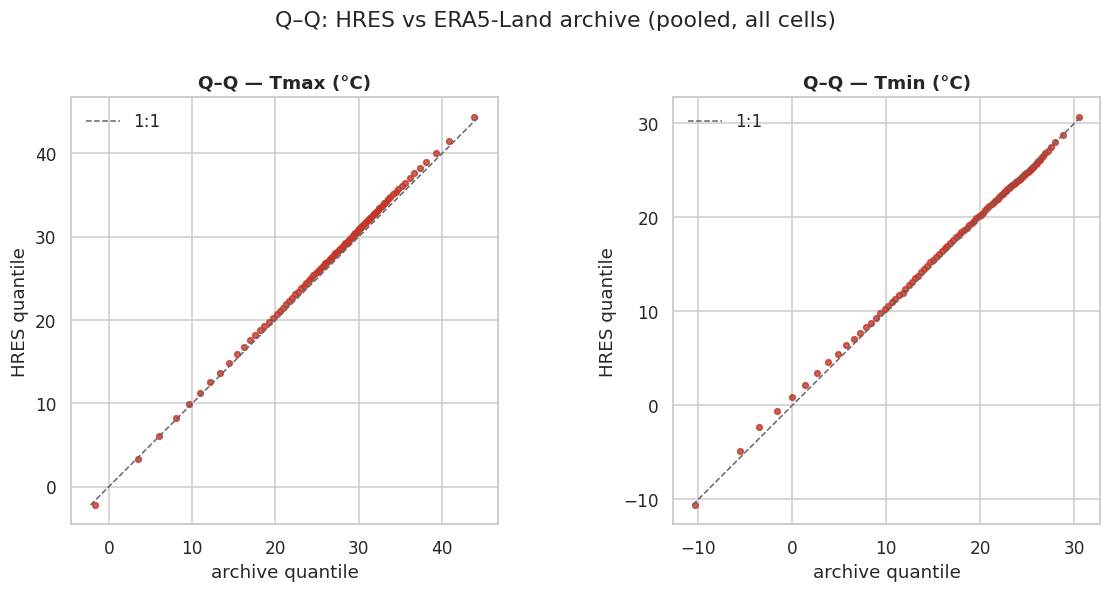

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
for ax, met in zip(axes, ['tmax_C', 'tmin_C']):
    d = df[df.metric == met]
    x, y = qq_xy(d.archive, d.hres)
    lim = [min(x.min(), y.min()), max(x.max(), y.max())]
    ax.plot(lim, lim, '--', color='0.4', lw=1, label='1:1')
    ax.scatter(x, y, s=14, color='#c0392b', alpha=.8)
    ax.set(xlabel='archive quantile', ylabel='HRES quantile',
           title=f'Q–Q — {LABEL[met]}')
    ax.set_aspect('equal'); ax.legend(loc='upper left', frameon=False)
fig.suptitle('Q–Q: HRES vs ERA5-Land archive (pooled, all cells)', y=1.02)
fig.tight_layout(); plt.show()

Same Q–Q for **Tmax**, now split by feature — one curve (hue) per group, ≤4 hues each.

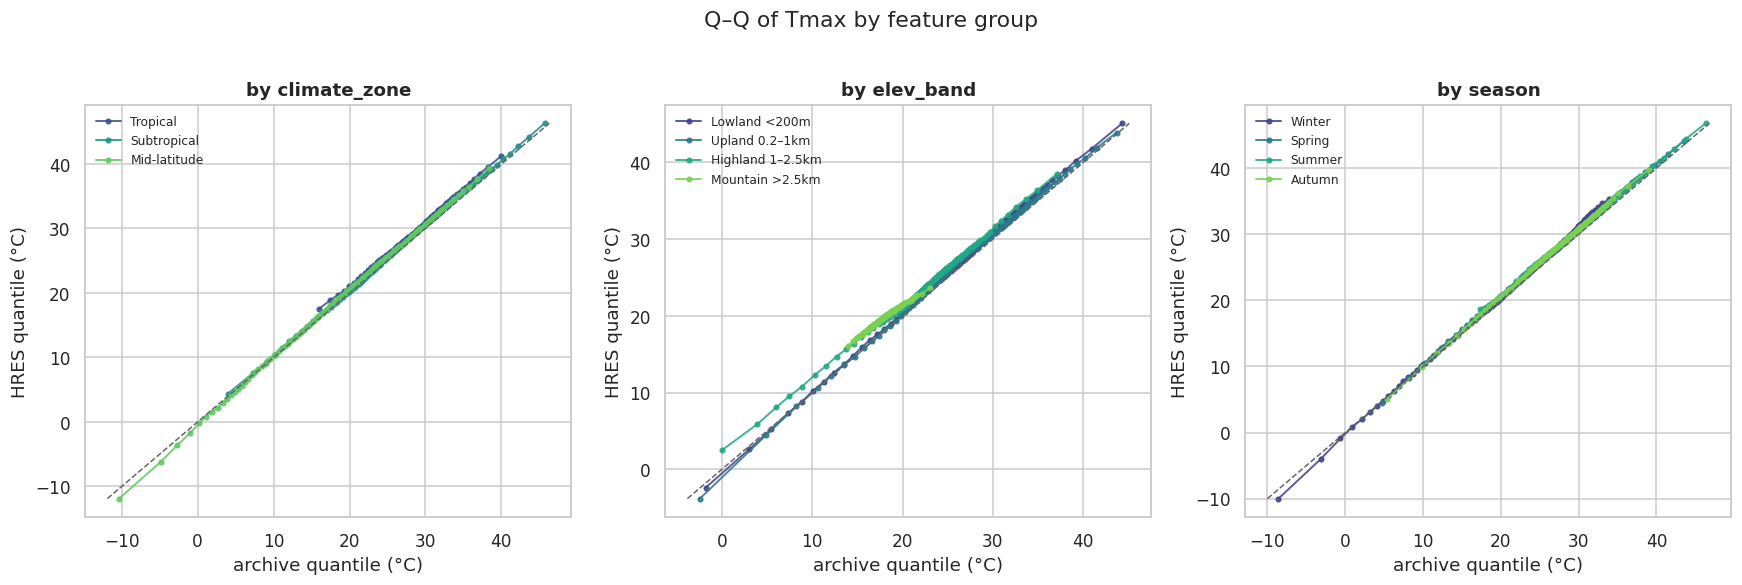

In [8]:
feats = ['climate_zone', 'elev_band', 'season']
d = df[df.metric == 'tmax_C']
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))
for ax, feat in zip(axes, feats):
    cats = used_cats(d[feat])
    pal = sns.color_palette('viridis', len(cats))
    allv = []
    for g, c in zip(cats, pal):
        x, y = qq_xy(d[d[feat] == g].archive, d[d[feat] == g].hres)
        ax.plot(x, y, '-o', ms=3, lw=1.3, color=c, alpha=.85, label=g)
        allv += [x, y]
    allv = np.concatenate(allv); lim = [allv.min(), allv.max()]
    ax.plot(lim, lim, '--', color='0.4', lw=1)
    ax.set(xlabel='archive quantile (°C)', ylabel='HRES quantile (°C)', title=f'by {feat}')
    ax.legend(fontsize=8, frameon=False)
fig.suptitle('Q–Q of Tmax by feature group', y=1.02)
fig.tight_layout(); plt.show()

## 3 · Distribution of differences, cut different ways

**Pooled** daily differences, all four metrics. Red dashed = mean (precip clipped to ±30 mm for display).

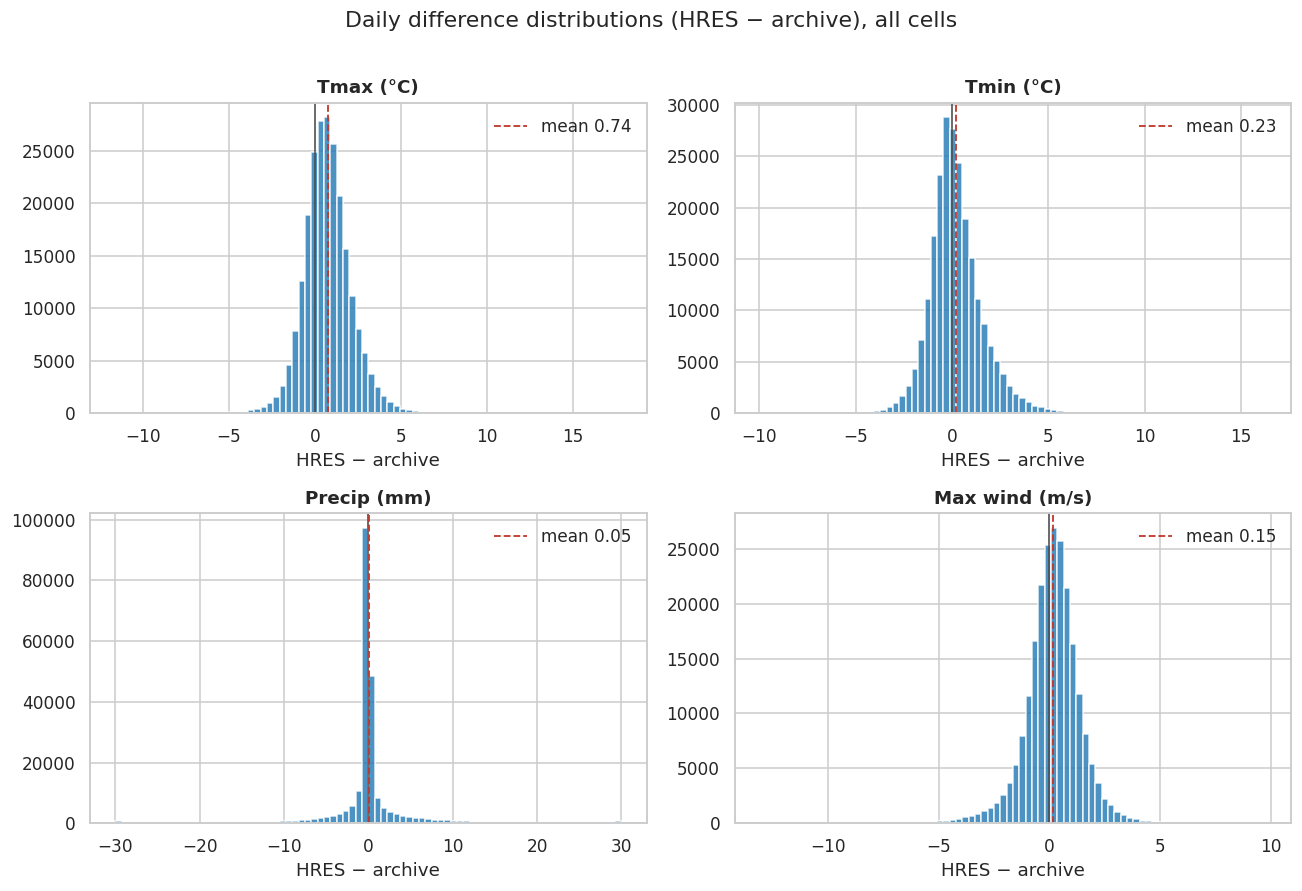

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, met in zip(axes.ravel(), METRICS):
    d = df[df.metric == met]['diff']
    show = d.clip(-30, 30) if met == 'precip_mm' else d
    ax.hist(show, bins=80, color='#2c7fb8', alpha=.85)
    ax.axvline(0, color='0.3', lw=1)
    ax.axvline(d.mean(), color='#c0392b', ls='--', lw=1.2, label=f'mean {d.mean():.2f}')
    ax.set(title=LABEL[met], xlabel='HRES − archive'); ax.legend(frameon=False)
fig.suptitle('Daily difference distributions (HRES − archive), all cells', y=1.01)
fig.tight_layout(); plt.show()

**By cell** — distribution of each cell's *mean* bias (systematic per-location offset).

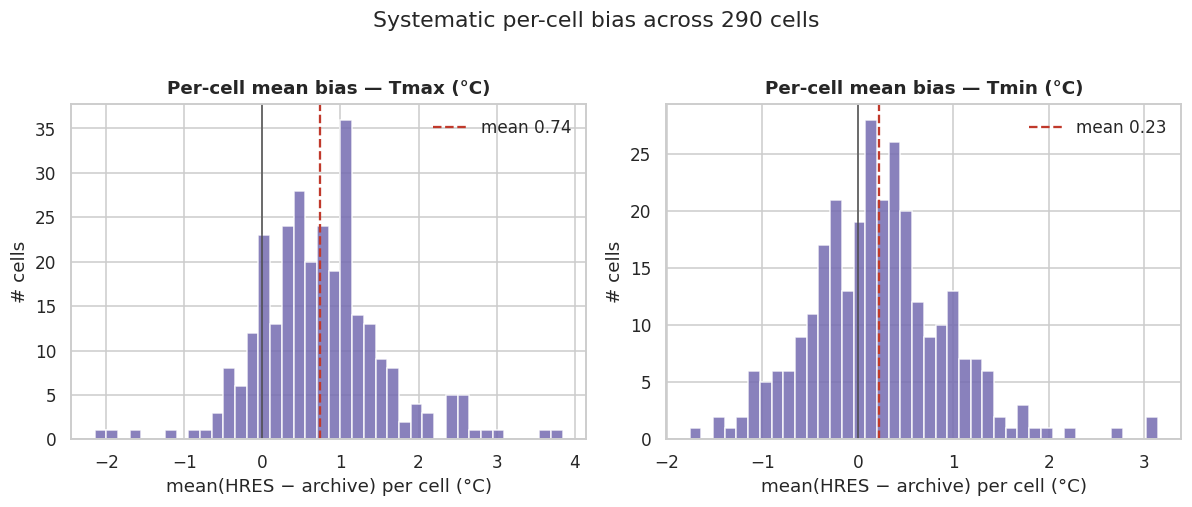

In [10]:
cb = df.groupby(['cell_id', 'metric'])['diff'].mean().unstack()
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, met in zip(axes, ['tmax_C', 'tmin_C']):
    v = cb[met]
    ax.hist(v, bins=40, color='#756bb1', alpha=.85)
    ax.axvline(0, color='0.3', lw=1)
    ax.axvline(v.mean(), color='#c0392b', ls='--', label=f'mean {v.mean():.2f}')
    ax.set(title=f'Per-cell mean bias — {LABEL[met]}',
           xlabel='mean(HRES − archive) per cell (°C)', ylabel='# cells')
    ax.legend(frameon=False)
fig.suptitle(f'Systematic per-cell bias across {cb.shape[0]} cells', y=1.02)
fig.tight_layout(); plt.show()

**By cell, geographically** — where HRES runs warm (red) vs cold (blue).

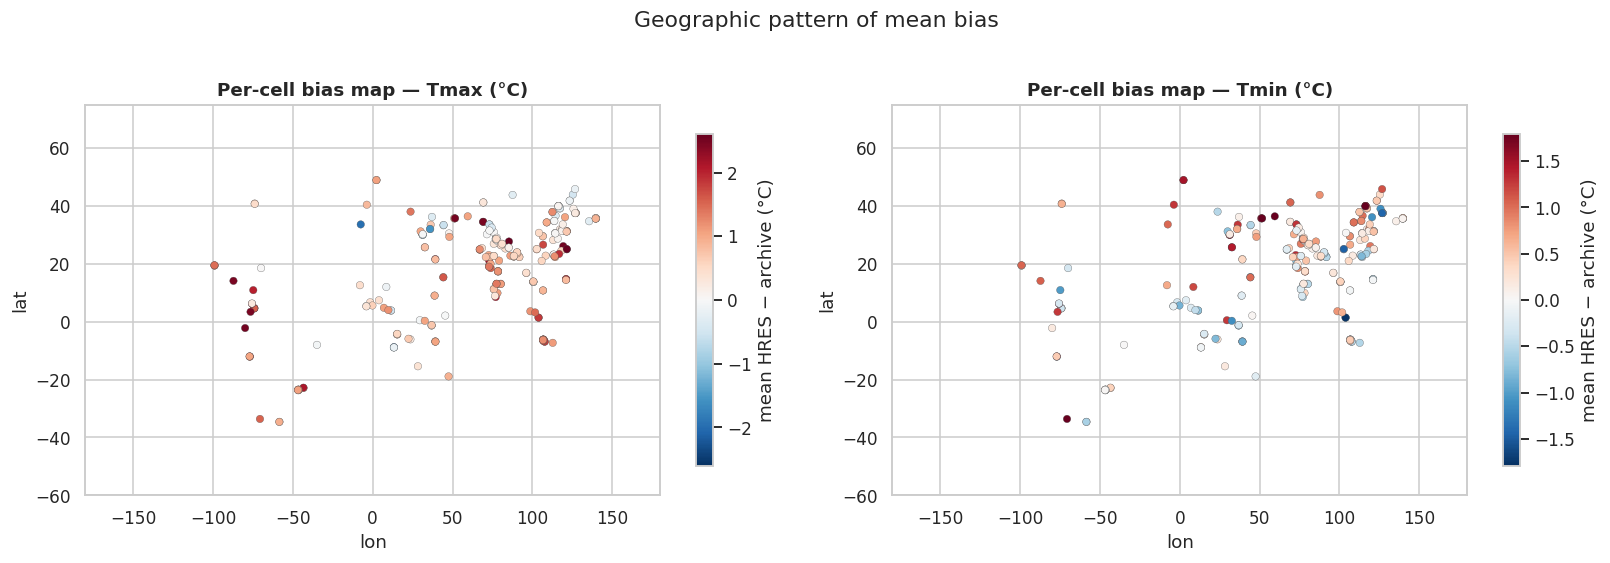

In [11]:
g = (df.groupby(['cell_id', 'metric'])
       .agg(d=('diff', 'mean'), lat=('lat', 'first'), lon=('lon', 'first'))
       .reset_index())
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, met in zip(axes, ['tmax_C', 'tmin_C']):
    s = g[g.metric == met]
    vmax = np.nanpercentile(s.d.abs(), 98)
    sc = ax.scatter(s.lon, s.lat, c=s.d, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                    s=24, edgecolor='0.3', lw=.2)
    plt.colorbar(sc, ax=ax, label='mean HRES − archive (°C)', shrink=.85)
    ax.set(title=f'Per-cell bias map — {LABEL[met]}', xlabel='lon', ylabel='lat',
           xlim=(-180, 180), ylim=(-60, 75))
fig.suptitle('Geographic pattern of mean bias', y=1.02)
fig.tight_layout(); plt.show()

**By geographic feature** — Tmax error density by climate zone and by elevation band.

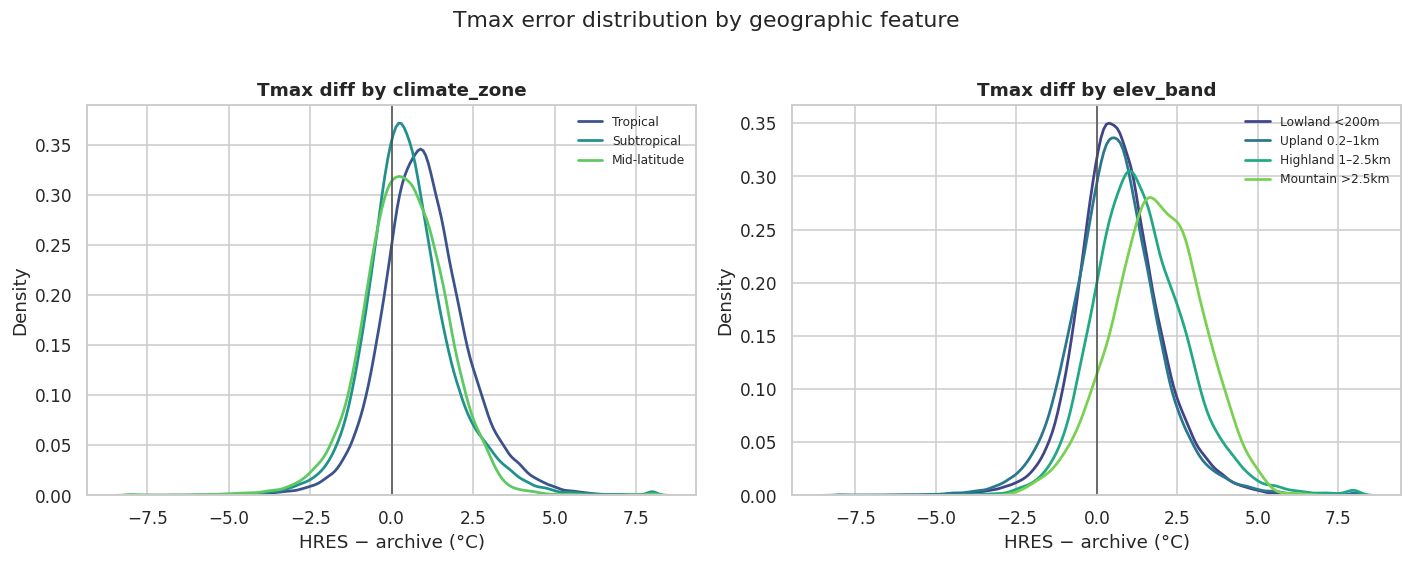

In [12]:
d = df[df.metric == 'tmax_C']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, feat in zip(axes, ['climate_zone', 'elev_band']):
    cats = used_cats(d[feat])
    for grp, c in zip(cats, sns.color_palette('viridis', len(cats))):
        sns.kdeplot(d[d[feat] == grp]['diff'].clip(-8, 8), ax=ax, color=c, lw=1.8, label=grp)
    ax.axvline(0, color='0.3', lw=1)
    ax.set(title=f'Tmax diff by {feat}', xlabel='HRES − archive (°C)')
    ax.legend(fontsize=8, frameon=False)
fig.suptitle('Tmax error distribution by geographic feature', y=1.02)
fig.tight_layout(); plt.show()

**By season** (hemisphere-aligned). Tmax and Tmin error densities.

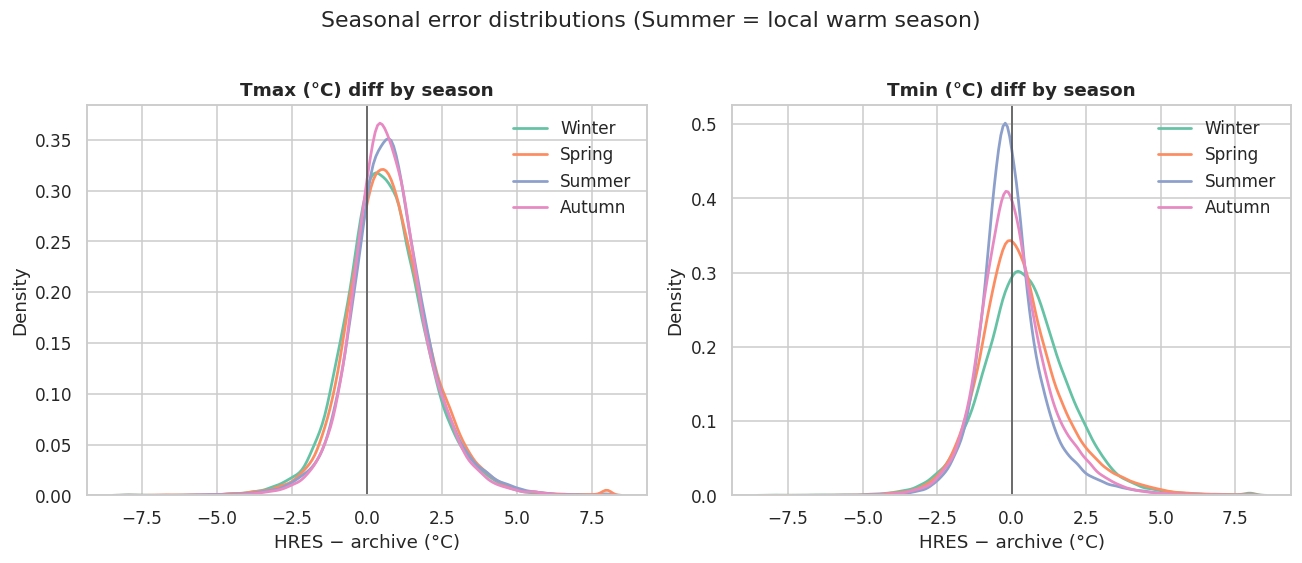

In [13]:
order = ['Winter', 'Spring', 'Summer', 'Autumn']
pal = dict(zip(order, sns.color_palette('Set2', 4)))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, met in zip(axes, ['tmax_C', 'tmin_C']):
    d = df[df.metric == met]
    for s in order:
        sns.kdeplot(d[d.season == s]['diff'].clip(-8, 8), ax=ax, color=pal[s], lw=1.8, label=s)
    ax.axvline(0, color='0.3', lw=1)
    ax.set(title=f'{LABEL[met]} diff by season', xlabel='HRES − archive (°C)')
    ax.legend(frameon=False)
fig.suptitle('Seasonal error distributions (Summer = local warm season)', y=1.02)
fig.tight_layout(); plt.show()

## 4 · At the extremes (the important part)

Extremes defined **per cell** (each cell's own 5% tail of the observed/archive value),
so hot/cold/wet means "extreme *for that place*".

Error on extreme days vs all days — densities overlaid.

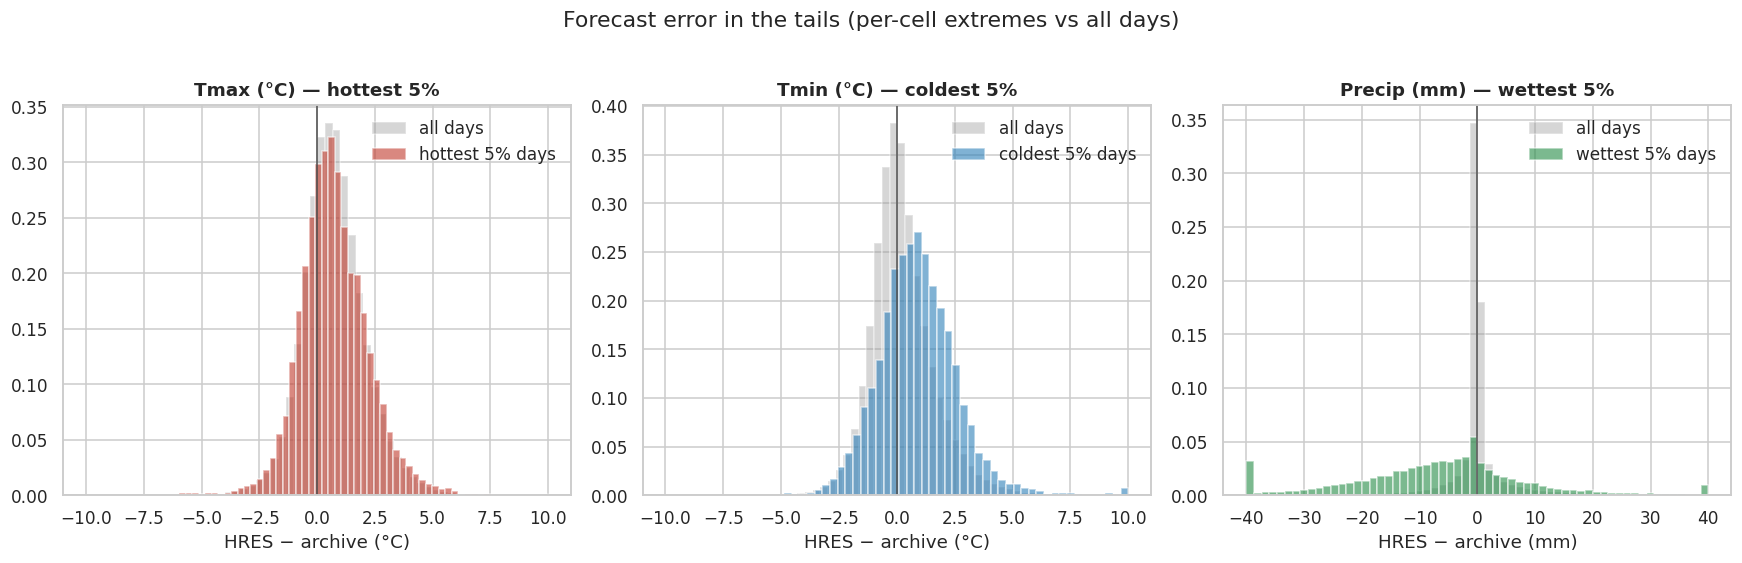

In [14]:
def tail_mask(d, hi=True, q=0.95):
    thr = d.groupby('cell_id')['archive'].transform(
        lambda s: s.quantile(q if hi else 1 - q))
    return d['archive'] >= thr if hi else d['archive'] <= thr

panels = [('tmax_C', True,  '#c0392b', 'hottest 5%', 10),
          ('tmin_C', False, '#2c7fb8', 'coldest 5%', 10),
          ('precip_mm', True, '#238b45', 'wettest 5%', 40)]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (met, hi, col, lab, clip) in zip(axes, panels):
    d = df[df.metric == met]
    ax.hist(d['diff'].clip(-clip, clip), bins=60, density=True, alpha=.4,
            color='0.6', label='all days')
    ax.hist(d[tail_mask(d, hi)]['diff'].clip(-clip, clip), bins=60, density=True,
            alpha=.6, color=col, label=lab + ' days')
    ax.axvline(0, color='0.3', lw=1)
    unit = 'mm' if met == 'precip_mm' else '°C'
    ax.set(title=f'{LABEL[met]} — {lab}', xlabel=f'HRES − archive ({unit})')
    ax.legend(frameon=False)
fig.suptitle('Forecast error in the tails (per-cell extremes vs all days)', y=1.02)
fig.tight_layout(); plt.show()

**Conditional bias** — bin by the observed value (x), plot mean diff ± IQR (y).
Tells us whether the forecast drifts as it actually gets hot / cold.

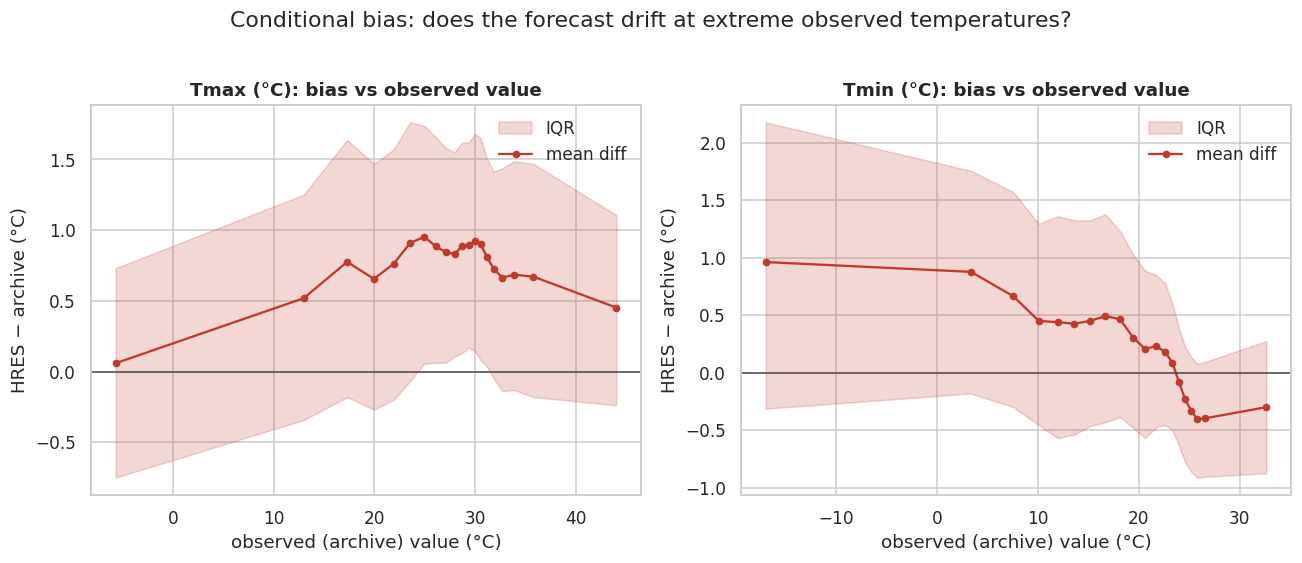

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, met in zip(axes, ['tmax_C', 'tmin_C']):
    d = df[df.metric == met].copy()
    edges = np.unique(np.quantile(d.archive, np.linspace(0, 1, 21)))
    d['b'] = pd.cut(d.archive, edges)
    gm = d.groupby('b', observed=True)['diff'].agg(['mean', 'count'])
    qs = d.groupby('b', observed=True)['diff'].quantile([.25, .75]).unstack().reindex(gm.index)
    xs = np.array([iv.mid for iv in gm.index])
    ax.fill_between(xs, qs[.25], qs[.75], alpha=.2, color='#c0392b', label='IQR')
    ax.plot(xs, gm['mean'], '-o', ms=4, color='#c0392b', label='mean diff')
    ax.axhline(0, color='0.3', lw=1)
    ax.set(title=f'{LABEL[met]}: bias vs observed value',
           xlabel='observed (archive) value (°C)', ylabel='HRES − archive (°C)')
    ax.legend(frameon=False)
fig.suptitle('Conditional bias: does the forecast drift at extreme observed temperatures?', y=1.02)
fig.tight_layout(); plt.show()

## 5 · Feature (x) vs per-cell bias (y)

One point per cell; black line = OLS fit (`r` shown).

**Tmax** per-cell bias vs elevation, |latitude|, population.

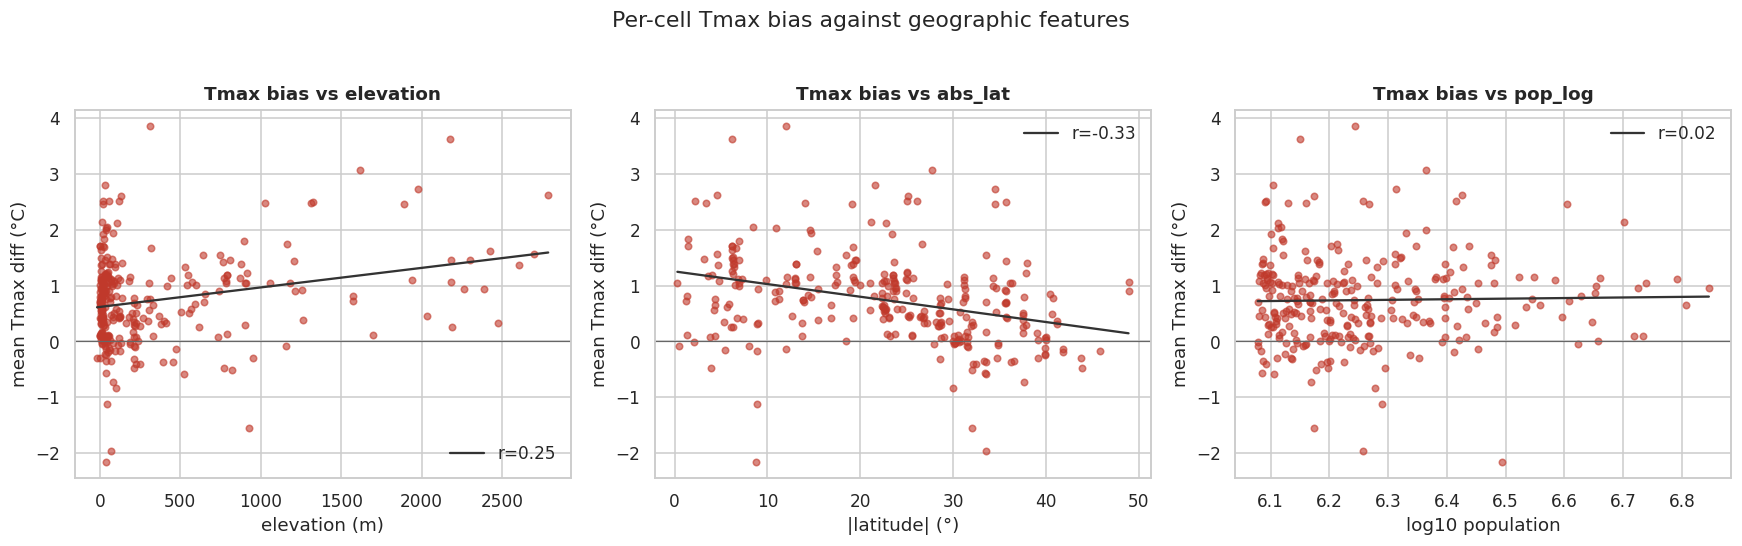

In [16]:
cb = (df[df.metric == 'tmax_C']
        .groupby('cell_id')
        .agg(d=('diff', 'mean'), elevation=('elevation', 'first'),
             abs_lat=('abs_lat', 'first'), pop_log=('pop_log', 'first'))
        .reset_index().dropna())
specs = [('elevation', 'elevation (m)'), ('abs_lat', '|latitude| (°)'),
         ('pop_log', 'log10 population')]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, (col, lab) in zip(axes, specs):
    ax.scatter(cb[col], cb.d, s=18, color='#c0392b', alpha=.6)
    m, b, rr, p, _ = stats.linregress(cb[col], cb.d)
    xs = np.linspace(cb[col].min(), cb[col].max(), 50)
    ax.plot(xs, m * xs + b, color='0.2', lw=1.5, label=f'r={rr:.2f}')
    ax.axhline(0, color='0.4', lw=.8)
    ax.set(xlabel=lab, ylabel='mean Tmax diff (°C)', title='Tmax bias vs ' + col)
    ax.legend(frameon=False)
fig.suptitle('Per-cell Tmax bias against geographic features', y=1.03)
fig.tight_layout(); plt.show()

**Tmin** per-cell bias vs elevation, |latitude|, population.

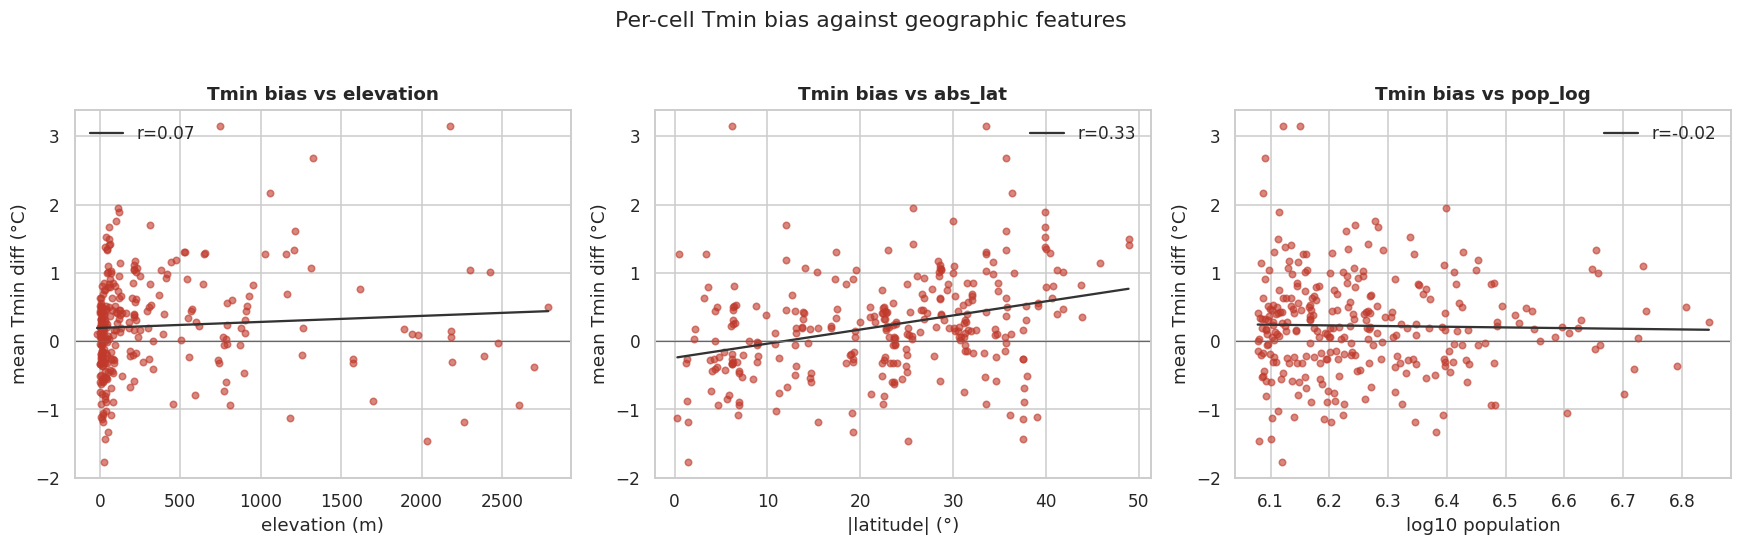

In [17]:
cb = (df[df.metric == 'tmin_C']
        .groupby('cell_id')
        .agg(d=('diff', 'mean'), elevation=('elevation', 'first'),
             abs_lat=('abs_lat', 'first'), pop_log=('pop_log', 'first'))
        .reset_index().dropna())
specs = [('elevation', 'elevation (m)'), ('abs_lat', '|latitude| (°)'),
         ('pop_log', 'log10 population')]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, (col, lab) in zip(axes, specs):
    ax.scatter(cb[col], cb.d, s=18, color='#c0392b', alpha=.6)
    m, b, rr, p, _ = stats.linregress(cb[col], cb.d)
    xs = np.linspace(cb[col].min(), cb[col].max(), 50)
    ax.plot(xs, m * xs + b, color='0.2', lw=1.5, label=f'r={rr:.2f}')
    ax.axhline(0, color='0.4', lw=.8)
    ax.set(xlabel=lab, ylabel='mean Tmin diff (°C)', title='Tmin bias vs ' + col)
    ax.legend(frameon=False)
fig.suptitle('Per-cell Tmin bias against geographic features', y=1.03)
fig.tight_layout(); plt.show()

**Annual cycle** of bias by hemisphere (mean diff per calendar month).

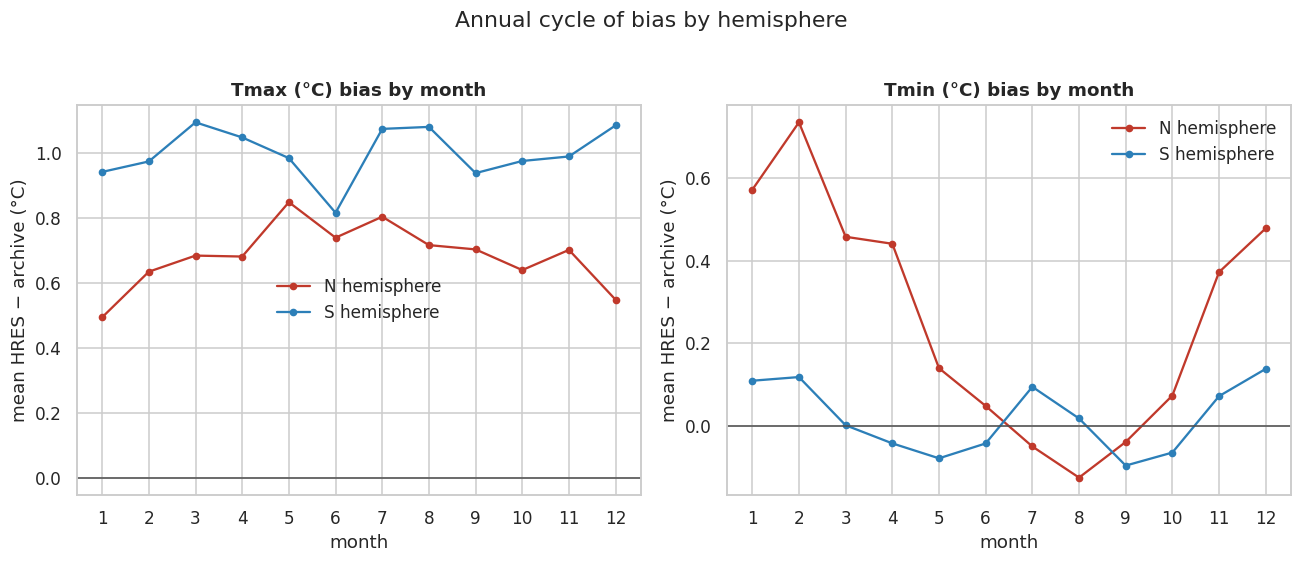

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, met in zip(axes, ['tmax_C', 'tmin_C']):
    d = df[df.metric == met]
    gm = d.groupby(['hemisphere', 'month'])['diff'].mean().reset_index()
    for hemi, c in zip(['N', 'S'], ['#c0392b', '#2c7fb8']):
        s = gm[gm.hemisphere == hemi]
        ax.plot(s.month, s['diff'], '-o', ms=4, color=c, label=f'{hemi} hemisphere')
    ax.axhline(0, color='0.3', lw=1); ax.set_xticks(range(1, 13))
    ax.set(title=f'{LABEL[met]} bias by month', xlabel='month',
           ylabel='mean HRES − archive (°C)')
    ax.legend(frameon=False)
fig.suptitle('Annual cycle of bias by hemisphere', y=1.02)
fig.tight_layout(); plt.show()

## 6 · Large differences: what drives them, and are they fixable?

The cuts above show a long-tailed error — Tmax's pooled **p95 sits right at ≈3 °C**. Here we
ask what is *behind* the cell-days where `|HRES − archive| > 3`, and how much of that tail
could be corrected.

To do it we bring in two per-cell features the earlier sections lacked, both straight from
the HRES acquisition job's resume ledger (`data/hres-forecast/.hres_progress.json`), which
records the actual HRES grid cell returned for each of our snapped 0.1° points:

- **`elev_diff_m` = ERA5-Land elevation − HRES elevation.** The two models carry *different
  orography*; where they disagree, the lapse rate alone forces a temperature gap
  (~6.5 °C per km of mismatch).
- **`dist_to_hres_km`** — haversine from our 0.1° point to the HRES O1280 cell center. The
  grid offset is itself part of the bias: a different place is different weather.

Core question: is the >3 mass **systematic** (a fixable per-cell / feature offset) or
**irreducible** day-to-day weather-timing noise?

In [ ]:
import json

# Two per-cell features the cuts above lacked — both recorded by the HRES acquisition job
# in its resume ledger (hres-forecast/.hres_progress.json), which logs the actual HRES grid
# cell the API returned for each of our snapped 0.1° points.
LEDGER = HRES_DIR / '.hres_progress.json'
ledger = json.load(open(LEDGER))['done']
led = pd.DataFrame([{'key': k, 'hres_lat': v['hres_lat'], 'hres_lon': v['hres_lon'],
                     'hres_elevation': v['hres_elevation']} for k, v in ledger.items()])

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0088
    p1, p2 = np.radians(lat1), np.radians(lat2)
    a = (np.sin(np.radians(lat2 - lat1) / 2) ** 2
         + np.cos(p1) * np.cos(p2) * np.sin(np.radians(lon2 - lon1) / 2) ** 2)
    return 2 * R * np.arcsin(np.sqrt(a))

# one row per cell, joined to the ledger by its '<lat>_<lon>' key
cellf = (df.groupby('cell_id')
           .agg(lat=('lat', 'first'), lon=('lon', 'first'),
                elevation=('elevation', 'first')).reset_index())
cellf['key'] = cellf.lat.map(lambda x: f'{x:g}') + '_' + cellf.lon.map(lambda x: f'{x:g}')
cellf = cellf.merge(led, on='key', how='left')
cellf['dist_to_hres_km'] = haversine_km(cellf.lat, cellf.lon, cellf.hres_lat, cellf.hres_lon)
cellf['elev_diff_m']     = cellf.elevation - cellf.hres_elevation   # ERA5-Land − HRES orography

# broadcast the three new features back onto the per-day long frame
cmap = cellf.set_index('cell_id')
for col in ['hres_elevation', 'elev_diff_m', 'dist_to_hres_km']:
    df[col] = df.cell_id.map(cmap[col])

matched = int(cellf.hres_elevation.notna().sum())
print(f'cells with an HRES ledger match: {matched} / {len(cellf)}')
print(cellf[['elevation', 'hres_elevation', 'elev_diff_m', 'dist_to_hres_km']]
      .describe().round(2).to_string())

### 6.1 · Systematic per-cell bias vs the grid mismatch

One point per cell: does a cell's *mean* bias track how far its ERA5 and HRES grids
disagree — in height (`elev_diff_m`) and in location (`dist_to_hres_km`)? The blue dashed
line on the elevation panels is the textbook **6.5 °C/km** lapse rate; if the cloud hugs
it, the systematic bias is largely an orographic artefact of the two models sampling
different terrain.

In [ ]:
# Does the *systematic* per-cell bias line up with the model-grid mismatch?
specs = [('elev_diff_m', 'ERA5 − HRES elevation (m)'),
         ('dist_to_hres_km', 'distance to HRES cell (km)')]
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for r, met in enumerate(['tmax_C', 'tmin_C']):
    cb = (df[df.metric == met]
            .groupby('cell_id')
            .agg(d=('diff', 'mean'), elev_diff_m=('elev_diff_m', 'first'),
                 dist_to_hres_km=('dist_to_hres_km', 'first'))
            .reset_index().dropna())
    for ax, (col, lab) in zip(axes[r], specs):
        ax.scatter(cb[col], cb.d, s=18, color='#c0392b', alpha=.55)
        slope, b, rr, _, _ = stats.linregress(cb[col], cb.d)
        xs = np.linspace(cb[col].min(), cb[col].max(), 50)
        ax.plot(xs, slope * xs + b, color='0.2', lw=1.5, label=f'r={rr:.2f}')
        ax.axhline(0, color='0.4', lw=.8)
        ax.set(xlabel=lab, ylabel=f'mean {LABEL[met]} diff', title=f'{LABEL[met]} bias vs {col}')
        ax.legend(frameon=False)
# overlay the textbook 6.5 °C/km lapse-rate expectation on the elevation panels
for r in range(2):
    xs = np.linspace(df.elev_diff_m.min(), df.elev_diff_m.max(), 50)
    axes[r][0].plot(xs, 0.0065 * xs, '--', color='#2c7fb8', lw=1.3, label='6.5 °C/km')
    axes[r][0].legend(frameon=False)
fig.suptitle('Per-cell mean bias vs orographic & grid-offset mismatch', y=1.01)
fig.tight_layout(); plt.show()

### 6.2 · How big is the >3 tail, and is it concentrated?

The share of cell-days that breach the threshold for each metric, and — for Tmax — whether
those breaches are spread evenly across cells or carried by a problem minority. A curve
bowed above the diagonal ⇒ concentrated, so a per-cell fix would only need to target a few
sites. The worst-cell table also shows their grid mismatch (`elev_diff_m`, `dist_km`).

In [ ]:
THR = 3.0   # "large" diff threshold (°C for temps; pooled Tmax p95 sits right here)

print(f'Fraction of cell-days with |HRES − archive| > {THR:g}:')
for met in METRICS:
    d = df[df.metric == met]['diff']
    unit = {'precip_mm': 'mm', 'wind_max_ms': 'm/s'}.get(met, '°C')
    print(f'  {LABEL[met]:16s} {(d.abs() > THR).mean() * 100:5.2f}%   (threshold in {unit}, n={len(d):,})')

# Concentration (Tmax): are the >3 days spread evenly, or carried by a problem minority?
met = 'tmax_C'
d = df[df.metric == met].assign(big=lambda x: x['diff'].abs() > THR)
rate = d.groupby('cell_id')['big'].mean().sort_values(ascending=False)
cnt  = d.groupby('cell_id')['big'].sum().sort_values(ascending=False)
cum  = cnt.cumsum() / cnt.sum()

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(np.arange(1, len(rate) + 1), rate.values * 100, color='#c0392b')
ax[0].set(xlabel='cell rank (worst first)', ylabel=f'% of that cell’s days |diff|>{THR:g}',
          title=f'Per-cell large-diff rate — {LABEL[met]}')
ax[1].plot(np.arange(1, len(cum) + 1) / len(cum) * 100, cum.values * 100, color='#2c7fb8')
ax[1].plot([0, 100], [0, 100], '--', color='0.6', label='even spread')
ax[1].set(xlabel='% of cells (worst first)', ylabel='cumulative % of all >3 days',
          title='Concentration of large diffs'); ax[1].legend(frameon=False)
fig.tight_layout(); plt.show()

worst = (d.groupby('cell_id')
           .agg(big_pct=('big', 'mean'), name=('name', 'first'),
                elev_diff_m=('elev_diff_m', 'first'), dist_km=('dist_to_hres_km', 'first'))
           .sort_values('big_pct', ascending=False).head(10))
worst['big_pct'] = (worst['big_pct'] * 100).round(1)
print('\nWorst 10 cells by Tmax large-diff rate:')
print(worst.round(1).to_string())

### 6.3 · What raises the odds of a large error?

`P(|diff| > 3)` for Tmax binned along each candidate feature (dashed line = the overall
rate). A curve that rises above the line means that feature genuinely *drives* the large
errors — and is therefore worth feeding to a correction.

In [ ]:
met = 'tmax_C'
d = df[df.metric == met].dropna(subset=['elev_diff_m', 'dist_to_hres_km']).copy()
d['big'] = d['diff'].abs() > THR
d['abs_elev_diff'] = d.elev_diff_m.abs()

def rate_by_bin(frame, col, nq=8):
    edges = np.unique(np.quantile(frame[col], np.linspace(0, 1, nq + 1)))
    g = frame.groupby(pd.cut(frame[col], edges), observed=True)['big'].mean() * 100
    return [iv.mid for iv in g.index], g.values

base = d['big'].mean() * 100
specs = [('abs_elev_diff', '|ERA5 − HRES elev| (m)'),
         ('dist_to_hres_km', 'distance to HRES cell (km)'),
         ('abs_lat', '|latitude| (°)')]
fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
for ax, (col, lab) in zip(axes[:3], specs):
    xs, ys = rate_by_bin(d, col)
    ax.plot(xs, ys, '-o', color='#c0392b')
    ax.axhline(base, color='0.5', ls='--', lw=1, label=f'overall {base:.1f}%')
    ax.set(xlabel=lab, ylabel=f'% days |diff|>{THR:g}', title=f'vs {col}')
    ax.legend(frameon=False)
gs = d.groupby('season', observed=True)['big'].mean() * 100
axes[3].bar(range(len(gs)), gs.values, color=sns.color_palette('Set2', len(gs)))
axes[3].axhline(base, color='0.5', ls='--', lw=1)
axes[3].set_xticks(range(len(gs))); axes[3].set_xticklabels(list(gs.index))
axes[3].set(ylabel=f'% days |diff|>{THR:g}', title='vs season')
fig.suptitle(f'What raises the chance of a large {LABEL[met]} error  ·  P(|diff| > {THR:g})', y=1.03)
fig.tight_layout(); plt.show()

### 6.4 · Is it fixable?

Two corrections, escalating in power: a single physical **lapse-rate** term that uses only
`elev_diff_m`, then **removing each cell's whole mean bias** — the ceiling for any static
per-cell / feature offset. The gap between them is the structure a nonlinear feature model
still has to learn; the residual after per-cell removal is the irreducible weather-timing
floor.

In [ ]:
# Is the >3 tail fixable? Two corrections, both applied per cell-day:
#   (a) physical lapse rate   : diff − 6.5 °C/km · elev_diff_m  (orographic term only)
#   (b) per-cell mean removal : diff − mean(diff for that cell) (the ceiling for ANY
#       static per-cell / feature offset — what an ML debias can approach, not exceed)
G = 0.0065
rows = []
for met in ['tmax_C', 'tmin_C']:
    d = df[df.metric == met].dropna(subset=['elev_diff_m']).copy()
    lap  = d['diff'] - G * d['elev_diff_m']
    anom = d['diff'] - d.groupby('cell_id')['diff'].transform('mean')
    cb = d.groupby('cell_id').agg(mb=('diff', 'mean'), ed=('elev_diff_m', 'first')).dropna()
    rows.append({'metric': LABEL[met],
                 'frac>3 raw':      (d['diff'].abs() > THR).mean() * 100,
                 'frac>3 lapse':    (lap.abs() > THR).mean() * 100,
                 'frac>3 per-cell': (anom.abs() > THR).mean() * 100,
                 'MAE raw':   d['diff'].abs().mean(),
                 'MAE lapse': lap.abs().mean(),
                 'r(bias, elev_diff)': cb.mb.corr(cb.ed)})
fix = pd.DataFrame(rows).set_index('metric').round(3)
print(fix.to_string())

labels = fix.index.tolist(); x = np.arange(len(labels)); w = 0.26
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - w, fix['frac>3 raw'],      w, label='raw',             color='#c0392b')
ax.bar(x,     fix['frac>3 lapse'],    w, label='− lapse rate',    color='#f39c12')
ax.bar(x + w, fix['frac>3 per-cell'], w, label='− per-cell mean', color='#2c7fb8')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set(ylabel=f'% of cell-days |diff| > {THR:g}',
       title='Large-diff tail before vs after correction')
ax.legend(frameon=False, title='correction'); fig.tight_layout(); plt.show()

### Takeaways

- **The tail is real but a minority** — a few % of Tmax/Tmin cell-days exceed 3 °C — and
  it is **concentrated**: a small set of cells carries a disproportionate share (the
  worst-cell table), so a *targeted* per-cell / feature fix beats a global constant.
- **Leading driver = orographic mismatch.** Per-cell mean Tmax bias tracks `elev_diff_m`
  (r ≈ 0.5) and roughly follows the textbook 6.5 °C/km lapse line; `dist_to_hres_km` and
  `|latitude|` add secondary structure, and the large-error *rate* climbs with all three.
  Tmin is less orographic (lower r) — its gap is more boundary-layer / radiative.
- **Mostly fixable.** A single physical lapse-rate term already trims the Tmax tail;
  **removing each cell's mean bias cuts the >3 rate by ~⅔ for Tmax (over half for Tmin)** —
  i.e. most large diffs are a *systematic, learnable* offset, not noise. The residual
  (~1–2 % of days) is the irreducible day-to-day weather-timing floor this archive↔forecast
  comparison can't close.
- **Next step.** The full nonlinear correction (era5 value + `elev_diff_m` +
  `dist_to_hres_km` + lat/lon + seasonal phase) is exactly what **`ml_debias.ipynb`** fits
  with a gradient-boosted tree — these features are *why* it can recover that systematic ⅔
  without a per-cell lookup.

## Notes & caveats

- **Convention:** `diff = HRES − archive`; +ve ⇒ HRES warmer/wetter/windier.
- **Skipped cells:** empty archive files are flagged in §1 and excluded (a handful,
  clustered on a couple of coastal sites — left for a follow-up agent).
- **Features used:** climate zone (|lat|), elevation band, population, hemisphere-aligned
  season; and in §6 two grid-mismatch features pulled from the HRES ledger —
  `elev_diff_m` (ERA5-Land − HRES orography) and `dist_to_hres_km` (0.1° point → HRES O1280
  cell). `overlap.csv`'s richer `regime` tags only cover 4 of the 300 cells, so they are
  not used here.
- **Extremes** are defined per-cell (each cell's own 5% tail) so they mean "extreme for
  that place," not globally.
- **§6 — large diffs:** "large" = `|diff| > 3` (°C for temps); decomposed into a fixable
  systematic part (per-cell mean / orographic lapse term) vs an irreducible weather-timing
  floor. The full nonlinear correction lives in `ml_debias.ipynb`.
- ~15 figures total, ≤4 hues per panel, by design.